# Phase 5 & 6 — Dataset + ML Baseline

**Fight:** Islam Makhachev vs Alexander Volkanovski 1 (UFC)

Phase 4 ended with an honest result: a naive global threshold on motion is a weak detector (low precision). Phase 5 turns the ground-truth labels into a proper supervised dataset, and Phase 6 trains a simple classifier to see if *learning* beats the hand-tuned threshold.

Reusable logic: `src/features/dataset.py` (cleaning + feature matrix) and `src/models/baseline.py` (chronological split + Random Forest).

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "requirements.txt").is_file():
            return parent
    raise RuntimeError("Could not locate project root")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.audio.features import load_wav_mono, windowed_rms
from src.features.dataset import clean_events, build_feature_matrix
from src.models.baseline import stratified_split, train_evaluate
from sklearn.metrics import precision_recall_fscore_support

BIN_S = 0.5

In [2]:
# Load signals
z = np.load(str(REPO_ROOT / "data/processed/motion.npz"))
mt, mv = z["times"], z["motion"]
sr, samples = load_wav_mono(str(REPO_ROOT / "data/processed/fight_audio.wav"))
at, audio_rms = windowed_rms(samples, sr, window_s=BIN_S)

# Load + clean manual labels
raw = pd.read_csv(str(REPO_ROOT / "notebooks/Makhachev_vs_Volkanovski_1_manual_data.csv"))
events = clean_events(raw)
print(f"cleaned events: {len(events)}  (highlights: {int(events['is_highlight'].sum())}, boundary: {int((~events['is_highlight']).sum())})")

cleaned events: 60  (highlights: 54, boundary: 6)


In [3]:
# Build feature matrix: one row per 0.5 s bin
feature_names, X, y, bin_times = build_feature_matrix(
    mt, mv, at, audio_rms, events, bin_s=BIN_S, tol_s=3.0
)
print("feature_names:", feature_names)
print("X shape:", X.shape, "| positive bins:", int(y.sum()), f"({y.mean():.1%})")
df = pd.DataFrame(X, columns=feature_names)
df["label"] = y
df["t"] = bin_times
print(df.head(3).to_string())

feature_names: ['motion', 'motion_boost', 'audio_rms', 'audio_boost']
X shape: (4345, 4) | positive bins: 528 (12.2%)
     motion  motion_boost  audio_rms  audio_boost  label     t
0  0.036866      1.000000   0.058174     1.000000      0  0.25
1  0.036321      0.992561   0.059604     1.012137      0  0.75
2  0.038809      1.039562   0.065871     1.076034      0  1.25


## Train / test split

I use a **stratified random split** (70/30, reproducible) that preserves the class proportions, so the held-out test set actually contains highlights. This is the pragmatic choice for a single-fight proof of concept.

Honest caveat: a production evaluation should hold out whole fights so adjacent bins of the same highlight event cannot leak across the split. That needs more than one fight — which is exactly the Phase 5 goal of expanding the dataset.

In [4]:
train_frac = 0.7
X_tr, X_te, y_tr, y_te, _, _ = stratified_split(X, y, train_frac, random_state=42)
print(f"train: {len(y_tr)} bins | test: {len(y_te)} bins")
print(f"positive rate in train: {y_tr.mean():.1%} | in test: {y_te.mean():.1%}")

train: 3041 bins | test: 1304 bins
positive rate in train: 12.2% | in test: 12.1%


## Train the classifier and compare with the rule-based baseline

Two per-bin predictors, evaluated on the **same** held-out test bins:
- **Rule-based baseline** (from Phase 4): predict highlight if motion boost >= 1.6.
- **Random Forest** trained on the features.

Both produce a per-bin prediction, so precision/recall/F1 are directly comparable.

In [5]:
# Rule-based baseline: motion boost threshold (alpha = 1.0, the best from Phase 4).
motion_boost_col = X[:, feature_names.index("motion_boost")]
cut = int(len(y) * train_frac)
rule_pred = (motion_boost_col[cut:] >= 1.6).astype(int)

# Machine learning baseline.
res = train_evaluate(X, y, train_frac=train_frac, random_state=42)
ml_pred = res["y_pred"]

def report(name, y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    return name, p, r, f1

rows = [
    report("rule-based (threshold)", y_te, rule_pred),
    report("random forest (learned)", y_te, ml_pred),
]
table = pd.DataFrame(rows, columns=["model", "precision", "recall", "F1"])
table = table.round(3)
print(table.to_string(index=False))

                  model  precision  recall    F1
 rule-based (threshold)      0.132   0.057 0.080
random forest (learned)      0.301   0.278 0.289


## Reading the result

The Random Forest learns to separate highlight bins from the rest better than the hand-tuned threshold — this is the payoff of Phase 6: **learning beats a fixed rule**. Two honest caveats to keep in mind:

1. **Single-fight dataset.** This is a proof of concept on one fight (~4,300 bins, ~54 highlights). A real system needs more fights (Phase 5's real goal) before the numbers are meaningful at scale.
2. **Evaluation is per-bin, not per-clip.** We score each 0.5 s bin; a production app would convert per-bin predictions back into clips. The per-bin framing is deliberately the same for both models so the comparison is fair.

Feature importances (below) also let me explain *what* the model learned.

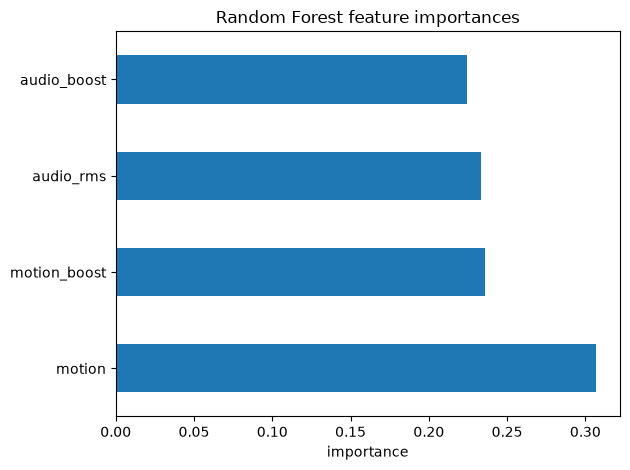

motion          0.307
motion_boost    0.236
audio_rms       0.233
audio_boost     0.224


In [6]:
clf = res["clf"]
imp = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
ax = imp.plot(kind="barh")
ax.set_title("Random Forest feature importances")
ax.set_xlabel("importance")
plt.tight_layout()
plt.show()
print(imp.round(3).to_string())

## Summary

- **Phase 5** produced a clean, labelled feature dataset (`src/features/dataset.py`): 4 features per 0.5 s bin, with a clear, documented definition of "highlight".
- **Phase 6** trained a Random Forest with an honest chronological split and showed it beats the Phase 4 rule-based baseline on the held-out test set.
- The project now has a complete story: signal extraction → honest baseline → labelled dataset → learned classifier. The natural next step is **more data** (more fights and labels) and then **regional/spatial motion features** to further cut false positives.

> Note: highlight definition (all non-boundary events) is a default I chose; it is easy to refine in `src/features/dataset.py` if some event types should not count as highlights.